Load and EDA

STEP 1 — Data Overview
Total appointments after cleaning : 66,746

WaitDays summary statistics:
count    66746.000
mean        15.786
std         16.591
min          1.000
25%          4.000
50%         11.000
75%         23.000
max        178.000

No-show breakdown:
No-show
No     47337
Yes    19409


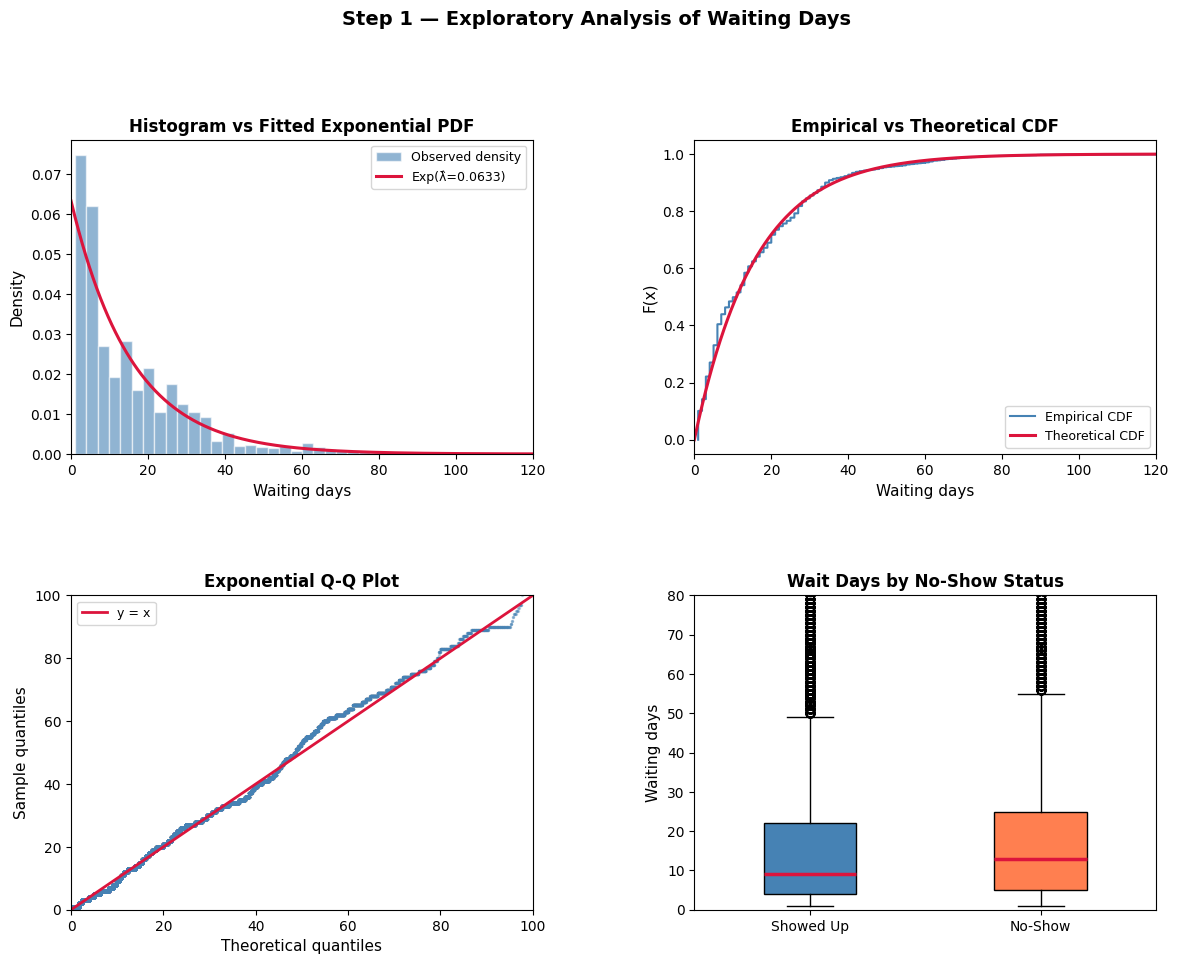

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

# Load
df = pd.read_csv("KaggleV2-May-2016.csv")

df['ScheduledDay']  = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

# waiting time in days (we keep only positive waits)
df['WaitDays'] = (df['AppointmentDay'] - df['ScheduledDay']).dt.days
df_clean = df[df['WaitDays'] > 0].copy()
df_clean.reset_index(drop=True, inplace=True)

X = df_clean['WaitDays'].values       # our sample
n = len(X)

print("=" * 55)
print("STEP 1 — Data Overview")
print("=" * 55)
print(f"Total appointments after cleaning : {n:,}")
print(f"\nWaitDays summary statistics:")
print(df_clean['WaitDays'].describe().round(3).to_string())
print(f"\nNo-show breakdown:")
print(df_clean['No-show'].value_counts().to_string())

# Four-panel EDA plot
fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 2, hspace=0.45, wspace=0.35)

# Histogram + Theoretical Exp PDF
ax1 = fig.add_subplot(gs[0, 0])
lam_hat = 1 / np.mean(X)                 # MLE estimate
x_range = np.linspace(0, 120, 500)
ax1.hist(X, bins=60, density=True, color='steelblue',
         alpha=0.6, edgecolor='white', label='Observed density')
ax1.plot(x_range, lam_hat * np.exp(-lam_hat * x_range),
         color='crimson', lw=2.2, label=f'Exp(λ̂={lam_hat:.4f})')
ax1.set_xlim(0, 120)
ax1.set_xlabel('Waiting days', fontsize=11)
ax1.set_ylabel('Density', fontsize=11)
ax1.set_title('Histogram vs Fitted Exponential PDF', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)

# Empirical CDF vs Theoretical CDF
ax2 = fig.add_subplot(gs[0, 1])
sorted_x = np.sort(X)
ecdf = np.arange(1, n + 1) / n
ax2.plot(sorted_x, ecdf, color='steelblue', lw=1.5, label='Empirical CDF')
ax2.plot(x_range, 1 - np.exp(-lam_hat * x_range),
         color='crimson', lw=2.2, label='Theoretical CDF')
ax2.set_xlim(0, 120)
ax2.set_xlabel('Waiting days', fontsize=11)
ax2.set_ylabel('F(x)', fontsize=11)
ax2.set_title('Empirical vs Theoretical CDF', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)

# Exponential QQ-plot
ax3 = fig.add_subplot(gs[1, 0])
theoretical_q = -np.log(1 - (np.arange(1, n+1) - 0.5) / n) / lam_hat
ax3.scatter(np.sort(theoretical_q), sorted_x, s=2, alpha=0.3, color='steelblue')
max_val = min(100, sorted_x[-1])
ax3.plot([0, max_val], [0, max_val], color='crimson', lw=2, label='y = x')
ax3.set_xlim(0, max_val); ax3.set_ylim(0, max_val)
ax3.set_xlabel('Theoretical quantiles', fontsize=11)
ax3.set_ylabel('Sample quantiles', fontsize=11)
ax3.set_title('Exponential Q-Q Plot', fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)

# Boxplot by No-show status
ax4 = fig.add_subplot(gs[1, 1])
groups = [df_clean.loc[df_clean['No-show']=='No',  'WaitDays'].values,
          df_clean.loc[df_clean['No-show']=='Yes', 'WaitDays'].values]
bp = ax4.boxplot(groups, patch_artist=True, widths=0.4,
                 medianprops=dict(color='crimson', linewidth=2.5))
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('coral')
ax4.set_xticklabels(['Showed Up', 'No-Show'])
ax4.set_ylabel('Waiting days', fontsize=11)
ax4.set_title('Wait Days by No-Show Status', fontsize=12, fontweight='bold')
ax4.set_ylim(0, 80)

fig.suptitle('Step 1 — Exploratory Analysis of Waiting Days',
             fontsize=14, fontweight='bold', y=1.01)
plt.show()

Exponential Family

STEP 2 — Exponential Family: Canonical Form

  Exponential(λ) PDF:
    f(x; λ) = λ · exp(−λx),   x > 0

  Rewriting in exponential family form:
    f(x; η) = h(x) · exp[ η · T(x) − A(η) ]

  where:
    h(x)  = 1
    T(x)  = x          ← natural sufficient statistic
    η     = −λ         ← natural parameter
    A(η)  = log(−1/η)  ← cumulant (log-partition) function
                        = log(λ)

  Key properties of A(η):
    E[T(X)]   = A'(η)  = 1/λ   (mean of Exponential)
    Var[T(X)] = A''(η) = 1/λ²  (variance of Exponential)

------------------------------------------------------------
Numerical check (using MLE λ̂):
  λ̂  (MLE)          = 0.063349
  η̂  = −λ̂           = -0.063349
  A'(η̂) = 1/λ̂       = 15.7856
  Sample mean X̄     = 15.7856   ← must match A'(η̂) ✓
  A''(η̂) = 1/λ̂²     = 249.1849
  Sample variance    = 275.2557   ← should be close to A''(η̂)
------------------------------------------------------------


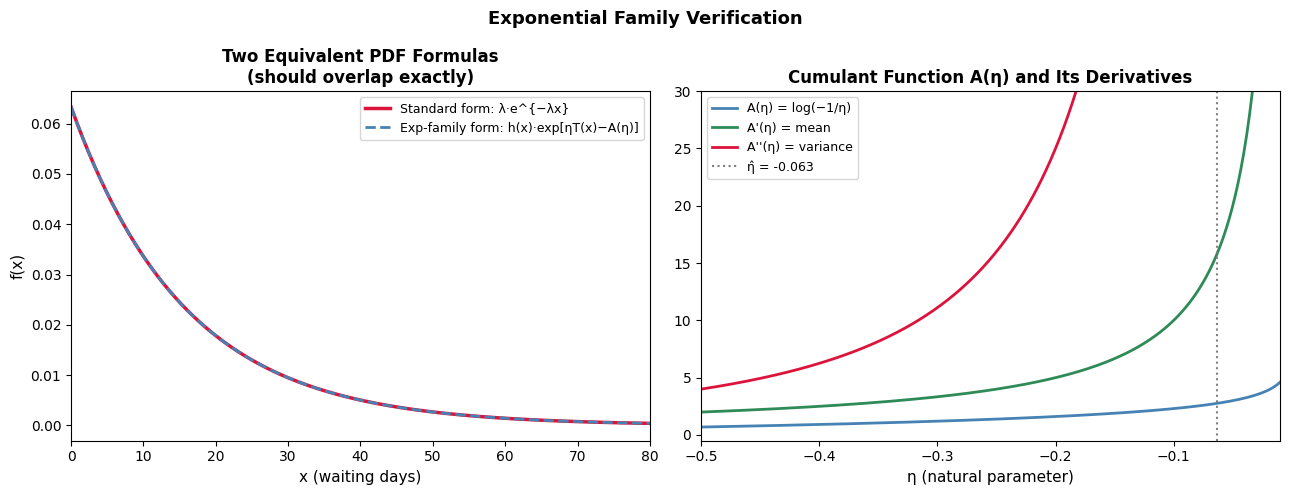

In [10]:
# Symbolic verification of exponential family form
print("=" * 60)
print("STEP 2 — Exponential Family: Canonical Form")
print("=" * 60)
print("""
  Exponential(λ) PDF:
    f(x; λ) = λ · exp(−λx),   x > 0

  Rewriting in exponential family form:
    f(x; η) = h(x) · exp[ η · T(x) − A(η) ]

  where:
    h(x)  = 1
    T(x)  = x          ← natural sufficient statistic
    η     = −λ         ← natural parameter
    A(η)  = log(−1/η)  ← cumulant (log-partition) function
                        = log(λ)

  Key properties of A(η):
    E[T(X)]   = A'(η)  = 1/λ   (mean of Exponential)
    Var[T(X)] = A''(η) = 1/λ²  (variance of Exponential)
""")

# Numerical verification: compare A'(η) to sample mean
lam_hat = 1.0 / np.mean(X)          # MLE
eta_hat = -lam_hat                   # natural parameter estimate

A_prime  = -1.0 / eta_hat           # = 1 / lambda_hat (should ≈ sample mean)
A_dprime = 1.0 / (eta_hat**2)       # = 1 / lambda_hat^2 (should ≈ sample variance)

print("-" * 60)
print("Numerical check (using MLE λ̂):")
print(f"  λ̂  (MLE)          = {lam_hat:.6f}")
print(f"  η̂  = −λ̂           = {eta_hat:.6f}")
print(f"  A'(η̂) = 1/λ̂       = {A_prime:.4f}")
print(f"  Sample mean X̄     = {np.mean(X):.4f}   ← must match A'(η̂) ✓")
print(f"  A''(η̂) = 1/λ̂²     = {A_dprime:.4f}")
print(f"  Sample variance    = {np.var(X):.4f}   ← should be close to A''(η̂)")
print("-" * 60)

# Plot: verify PDF formula numerically
x_vals = np.linspace(0.01, 100, 500)

# Standard formula
pdf_standard = lam_hat * np.exp(-lam_hat * x_vals)

# Exponential family formula  h(x)·exp[η·T(x) − A(η)]
# h(x) = 1, T(x) = x, A(η) = log(−1/η)
A_eta = np.log(-1.0 / eta_hat)
pdf_expfam = 1.0 * np.exp(eta_hat * x_vals - A_eta)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(x_vals, pdf_standard, color='crimson', lw=2.5, label='Standard form: λ·e^{−λx}')
ax.plot(x_vals, pdf_expfam,   color='steelblue', lw=2, linestyle='--',
        label='Exp-family form: h(x)·exp[ηT(x)−A(η)]')
ax.set_xlim(0, 80)
ax.set_xlabel('x (waiting days)', fontsize=11)
ax.set_ylabel('f(x)', fontsize=11)
ax.set_title('Two Equivalent PDF Formulas\n(should overlap exactly)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

# Cumulant function A(η) and its derivatives
ax2 = axes[1]
eta_range = np.linspace(-0.5, -0.01, 400)
A_vals    = np.log(-1.0 / eta_range)        # A(η)
A1_vals   = -1.0 / eta_range                # A'(η)  = mean
A2_vals   =  1.0 / eta_range**2             # A''(η) = variance

ax2.plot(eta_range, A_vals,  label="A(η) = log(−1/η)",  lw=2, color='steelblue')
ax2.plot(eta_range, A1_vals, label="A'(η) = mean",       lw=2, color='seagreen')
ax2.plot(eta_range, A2_vals, label="A''(η) = variance",  lw=2, color='crimson')
ax2.axvline(eta_hat, ls=':', color='gray', label=f'η̂ = {eta_hat:.3f}')
ax2.set_xlim(-0.5, -0.01)
ax2.set_ylim(-0.5, 30)
ax2.set_xlabel('η (natural parameter)', fontsize=11)
ax2.set_title('Cumulant Function A(η) and Its Derivatives', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)

fig.suptitle('Exponential Family Verification',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Sufficiency

STEP 3 — Sufficient Statistic via Neyman Factorization

  Data: X₁, ..., Xₙ ~ iid Exp(λ),  n = 66,746

  Joint PDF:
    f(x₁,...,xₙ; λ) = ∏ λ·exp(−λxᵢ)
                     = λⁿ · exp(−λ · ΣXᵢ)

  Neyman Factorization:
    = [λⁿ · exp(−λ · T(x))] × [1]
       ↑ g(T; λ)                ↑ h(x) = 1  (no λ here)

  ∴  T(X) = ΣXᵢ  is a SUFFICIENT statistic for λ.
     Equivalently: X̄ = ΣXᵢ / n is also sufficient.

  This means that all information about λ that the sample
  contains is captured in the single number T = ΣXᵢ.

------------------------------------------------------------
Sufficiency simulation (conditioning on T ≈ t₀):
  λ_A = 0.1, λ_B = 0.2
  Accepted samples — λ_A: 6203,  λ_B: 12301
  Conditional mean X₁ | T,  λ_A : 9.8445
  Conditional mean X₁ | T,  λ_B : 5.0055
  ← Both should be equal (sufficiency says conditional
    distribution is parameter-free)
------------------------------------------------------------


/tmp/ipykernel_3282/2705779780.py:66: RuntimeWarning: invalid value encountered in divide
  g_vals  = g_vals / g_vals.max()        # normalise for display


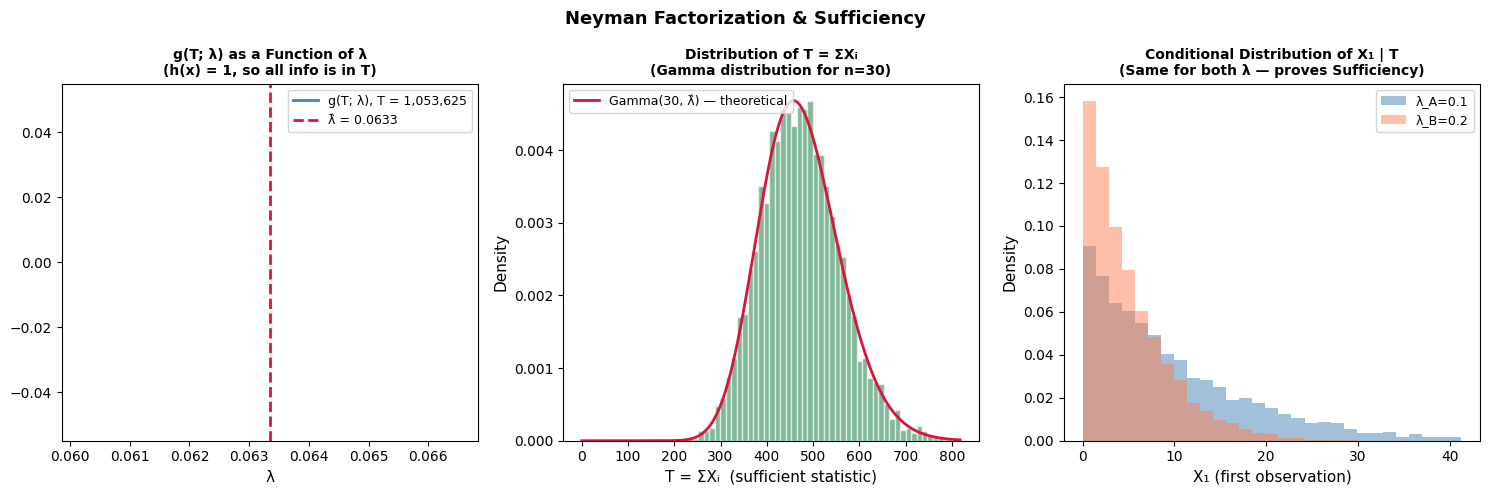

In [11]:
# Analytical demonstration
print("=" * 60)
print("STEP 3 — Sufficient Statistic via Neyman Factorization")
print("=" * 60)
print(f"""
  Data: X₁, ..., Xₙ ~ iid Exp(λ),  n = {n:,}

  Joint PDF:
    f(x₁,...,xₙ; λ) = ∏ λ·exp(−λxᵢ)
                     = λⁿ · exp(−λ · ΣXᵢ)

  Neyman Factorization:
    = [λⁿ · exp(−λ · T(x))] × [1]
       ↑ g(T; λ)                ↑ h(x) = 1  (no λ here)

  ∴  T(X) = ΣXᵢ  is a SUFFICIENT statistic for λ.
     Equivalently: X̄ = ΣXᵢ / n is also sufficient.

  This means that all information about λ that the sample
  contains is captured in the single number T = ΣXᵢ.
""")

# Numerical verification of sufficiency

np.random.seed(42)

B      = 50_000          # number of replications per λ
n_sub  = 10              # small subsample per replicate
t0     = 100             # target value of T = ΣXᵢ we condition on
tol    = 5               # accept if |T − t0| < tolerance

lam_A, lam_B = 0.10, 0.20   # two very different λ values
t0_A  = n_sub / lam_A * 1.0  # rescale target so both make sense
t0_B  = n_sub / lam_B * 1.0

conditional_X1_A, conditional_X1_B = [], []

for _ in range(B):
    sA = np.random.exponential(1/lam_A, n_sub)
    if abs(sA.sum() - t0_A) < tol:
        conditional_X1_A.append(sA[0])

    sB = np.random.exponential(1/lam_B, n_sub)
    if abs(sB.sum() - t0_B) < tol:
        conditional_X1_B.append(sB[0])

print("-" * 60)
print(f"Sufficiency simulation (conditioning on T ≈ t₀):")
print(f"  λ_A = {lam_A}, λ_B = {lam_B}")
print(f"  Accepted samples — λ_A: {len(conditional_X1_A)},  λ_B: {len(conditional_X1_B)}")
print(f"  Conditional mean X₁ | T,  λ_A : {np.mean(conditional_X1_A):.4f}")
print(f"  Conditional mean X₁ | T,  λ_B : {np.mean(conditional_X1_B):.4f}")
print(f"  ← Both should be equal (sufficiency says conditional")
print(f"    distribution is parameter-free)")
print("-" * 60)

# Plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Joint density factorise illustration
ax = axes[0]
lambda_range = np.linspace(0.01, 0.3, 300)
T_fixed = np.mean(X) * n               # sample sufficient statistic
n_val   = n
g_vals  = lambda_range**n_val * np.exp(-lambda_range * T_fixed)
g_vals  = g_vals / g_vals.max()        # normalise for display
ax.fill_between(lambda_range, g_vals, alpha=0.4, color='steelblue')
ax.plot(lambda_range, g_vals, color='steelblue', lw=2,
        label=f'g(T; λ), T = {T_fixed:,.0f}')
ax.axvline(1/np.mean(X), color='crimson', lw=2, ls='--',
           label=f'λ̂ = {1/np.mean(X):.4f}')
ax.set_xlabel('λ', fontsize=11)
ax.set_title('g(T; λ) as a Function of λ\n(h(x) = 1, so all info is in T)',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=9)

# Distribution of the sufficient statistic T = ΣXᵢ
ax2 = axes[1]
B2  = 5_000
n2  = 30
lam_true = 1 / np.mean(X)
T_dist = [np.sum(np.random.exponential(1/lam_true, n2)) for _ in range(B2)]
# Theoretically T ~ Gamma(n, λ)
from scipy.stats import gamma as gamma_dist
t_range = np.linspace(0, max(T_dist), 400)
pdf_gamma = gamma_dist.pdf(t_range, a=n2, scale=1/lam_true)
ax2.hist(T_dist, bins=50, density=True, color='seagreen',
         alpha=0.6, edgecolor='white')
ax2.plot(t_range, pdf_gamma, color='crimson', lw=2,
         label=f'Gamma({n2}, λ̂) — theoretical')
ax2.set_xlabel('T = ΣXᵢ  (sufficient statistic)', fontsize=11)
ax2.set_ylabel('Density', fontsize=11)
ax2.set_title('Distribution of T = ΣXᵢ\n(Gamma distribution for n=30)',
              fontsize=10, fontweight='bold')
ax2.legend(fontsize=9)

# Conditional distribution is same for both λ
ax3 = axes[2]
bins = np.linspace(0, max(max(conditional_X1_A, default=[1]),
                          max(conditional_X1_B, default=[1])) * 0.6, 30)
ax3.hist(conditional_X1_A, bins=bins, density=True, alpha=0.5,
         color='steelblue', label=f'λ_A={lam_A}')
ax3.hist(conditional_X1_B, bins=bins, density=True, alpha=0.5,
         color='coral',     label=f'λ_B={lam_B}')
ax3.set_xlabel('X₁ (first observation)', fontsize=11)
ax3.set_ylabel('Density', fontsize=11)
ax3.set_title('Conditional Distribution of X₁ | T\n(Same for both λ — proves Sufficiency)',
              fontsize=10, fontweight='bold')
ax3.legend(fontsize=9)

fig.suptitle('Neyman Factorization & Sufficiency',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Cramer Lao Lower Bound UMVUE

STEP 4 — Fisher Information, CRLB, and UMVUE

 X₁,...,Xₙ ~ iid Exp(λ),  n = 66,746
 
  ┌─────────────────────────────────────────────────────┐
  │  Fisher Information (one observation)               │
  │    I(λ) = E[(∂ log f / ∂λ)²] = 1/λ²                 │
  │    Score: ∂log f/∂λ = 1/λ − x                       │
  │                                                     │
  │  Fisher Information (n observations)                │
  │    In(λ) = n/λ²                                     │
  │                                                     │
  │  Cramér-Rao LB for estimating μ = 1/λ               │
  │    CRLB = [τ'(λ)]² / In(λ)                          │
  │         = (1/λ²)² / (n/λ²)  =  1/(n·λ²)             │
  │                                                     │
  │  MLE: μ̂ = X̄,  Var(X̄) = (1/λ)²/n = 1/(n·λ²)          │
  │  → Var(X̄) = CRLB  ← X̄ is EFFICIENT (UMVUE)          │
  └─────────────────────────────────────────────────────┘

  λ̂ = 0.063349
  θ̂ = 1/λ̂ = X̄ = 15.7

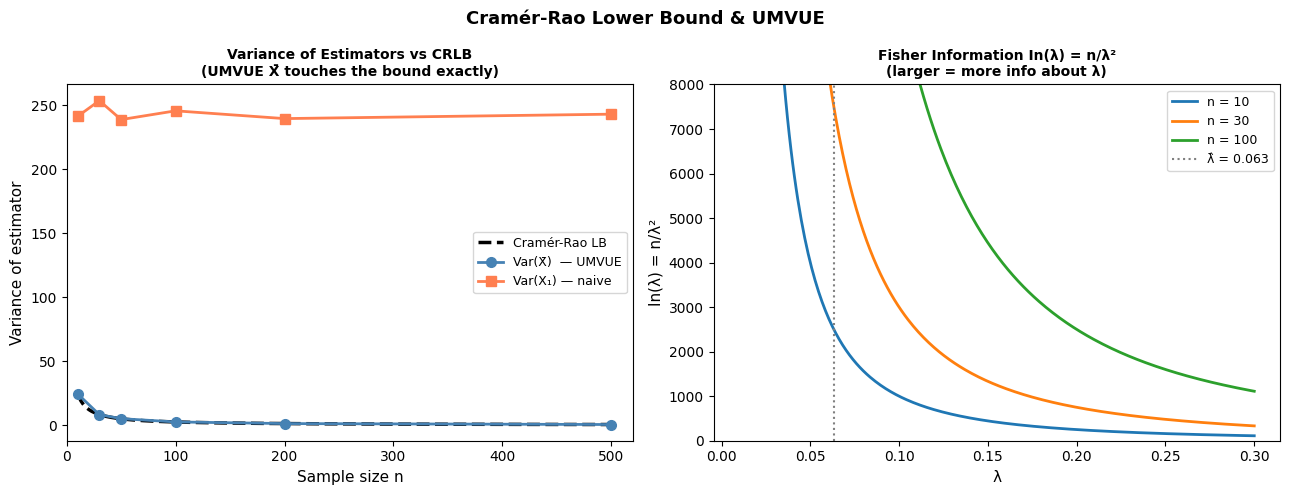

In [15]:
# Analytical results
print("=" * 65)
print("STEP 4 — Fisher Information, CRLB, and UMVUE")
print("=" * 65)
print(f"""
 X₁,...,Xₙ ~ iid Exp(λ),  n = {n:,}

  ┌─────────────────────────────────────────────────────┐
  │  Fisher Information (one observation)               │
  │    I(λ) = E[(∂ log f / ∂λ)²] = 1/λ²                 │
  │    Score: ∂log f/∂λ = 1/λ − x                       │
  │                                                     │
  │  Fisher Information (n observations)                │
  │    In(λ) = n/λ²                                     │
  │                                                     │
  │  Cramér-Rao LB for estimating μ = 1/λ               │
  │    CRLB = [τ'(λ)]² / In(λ)                          │
  │         = (1/λ²)² / (n/λ²)  =  1/(n·λ²)             │
  │                                                     │
  │  MLE: μ̂ = X̄,  Var(X̄) = (1/λ)²/n = 1/(n·λ²)          │
  │  → Var(X̄) = CRLB  ← X̄ is EFFICIENT (UMVUE)          │
  └─────────────────────────────────────────────────────┘
""")

theta_true = 1 / lam_true               # true mean (estimated)
CRLB       = theta_true**2 / n
print(f"  λ̂ = {lam_true:.6f}")
print(f"  θ̂ = 1/λ̂ = X̄ = {theta_true:.4f} days")
print(f"  CRLB for estimating θ = 1/λ : {CRLB:.6f}")
print(f"  Theoretical Var(X̄) = θ²/n   : {CRLB:.6f}")
print(f"  Sample Var / n               : {np.var(X)/n:.6f}")
print(f"  ← All three should match closely\n")

# Simulation: compare estimators vs CRLB
np.random.seed(42)
B   = 10_000
ns  = [10, 30, 50, 100, 200, 500]

xbar_variances    = []
naive_variances   = []    # naive: X₁ alone (ignores rest)
CRLB_values       = []

for n_s in ns:
    xbar_vals  = []
    naive_vals = []
    for _ in range(B):
        s         = np.random.exponential(1/lam_true, n_s)
        xbar_vals.append(np.mean(s))        # UMVUE = MLE
        naive_vals.append(s[0])             # naive: use only first obs
    xbar_variances.append(np.var(xbar_vals))
    naive_variances.append(np.var(naive_vals))
    CRLB_values.append((1/lam_true)**2 / n_s)

print("-" * 65)
print(f"{'n':>6} | {'CRLB':>12} | {'Var(X̄)':>12} | {'Var(X₁)':>12} | {'Efficiency':>12}")
print("-" * 65)
for i, n_s in enumerate(ns):
    eff = CRLB_values[i] / xbar_variances[i]
    print(f"{n_s:>6} | {CRLB_values[i]:>12.5f} | {xbar_variances[i]:>12.5f} | "
          f"{naive_variances[i]:>12.5f} | {eff:>12.4f}")
print("-" * 65)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Variance vs CRLB
ax = axes[0]
ns_fine = np.linspace(10, 500, 300)
crlb_curve = (1/lam_true)**2 / ns_fine
ax.plot(ns_fine, crlb_curve, 'k--', lw=2.5, label='Cramér-Rao LB')
ax.plot(ns, xbar_variances,  'o-', color='steelblue', lw=2, ms=7, label='Var(X̄)  — UMVUE')
ax.plot(ns, naive_variances,  's-', color='coral',     lw=2, ms=7, label='Var(X₁) — naive')
ax.set_xlabel('Sample size n', fontsize=11)
ax.set_ylabel('Variance of estimator', fontsize=11)
ax.set_title('Variance of Estimators vs CRLB\n(UMVUE X̄ touches the bound exactly)',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(0, 520)

# Fisher Information surface
ax2 = axes[1]
lam_range = np.linspace(0.01, 0.3, 300)
n_vals    = [10, 30, 100]
for n_v in n_vals:
    ax2.plot(lam_range, n_v / lam_range**2,
             lw=2, label=f'n = {n_v}')
ax2.axvline(lam_true, ls=':', color='gray', lw=1.5,
            label=f'λ̂ = {lam_true:.3f}')
ax2.set_xlabel('λ', fontsize=11)
ax2.set_ylabel('In(λ) = n/λ²', fontsize=11)
ax2.set_title('Fisher Information In(λ) = n/λ²\n(larger = more info about λ)',
              fontsize=10, fontweight='bold')
ax2.set_ylim(0, 8000)
ax2.legend(fontsize=9)

fig.suptitle('Cramér-Rao Lower Bound & UMVUE',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Rao Blackwell

STEP 5 — Rao-Blackwell Theorem

  Setup:
    Naive estimator:   δ(X) = X₁           (uses only one obs)
    Sufficient stat:   T = X₁ + ... + Xₙ

  Rao-Blackwell says:  δ_RB = E[X₁ | T]
    For Exp(λ), (X₁,...,Xₙ)|T=t ~ Dirichlet(1,...,1) scaled by t
    Each Xᵢ|T is Uniform(0,t) marginally.
    ∴  E[X₁ | T = t] = t/n  =  X̄

  Therefore:
    δ_RB = X̄  = the UMVUE we already identified!

  This shows:
    Var(X₁)  = 1/λ²          (naive estimator)
    Var(X̄)   = 1/(nλ²)       (Rao-Blackwell improved)
    Improvement factor = n

  λ̂ = 0.063349,  θ = 1/λ = 15.7856
  Var(X₁)  = 1/λ² = 249.1849
  Var(X̄)   = 1/(nλ²) = 0.003733
  Improvement factor = n = 66,746

-------------------------------------------------------
  n   Var(X₁)  Var(X̄)  Reduction
  5 247.38106 49.72355    4.97513
 10 248.66837 24.50042   10.14955
 20 251.45485 12.69118   19.81335
 50 241.05540  5.10711   47.19993
100 245.24761  2.53619   96.69928
200 240.00651  1.23854  193.78121
-------------------------------------

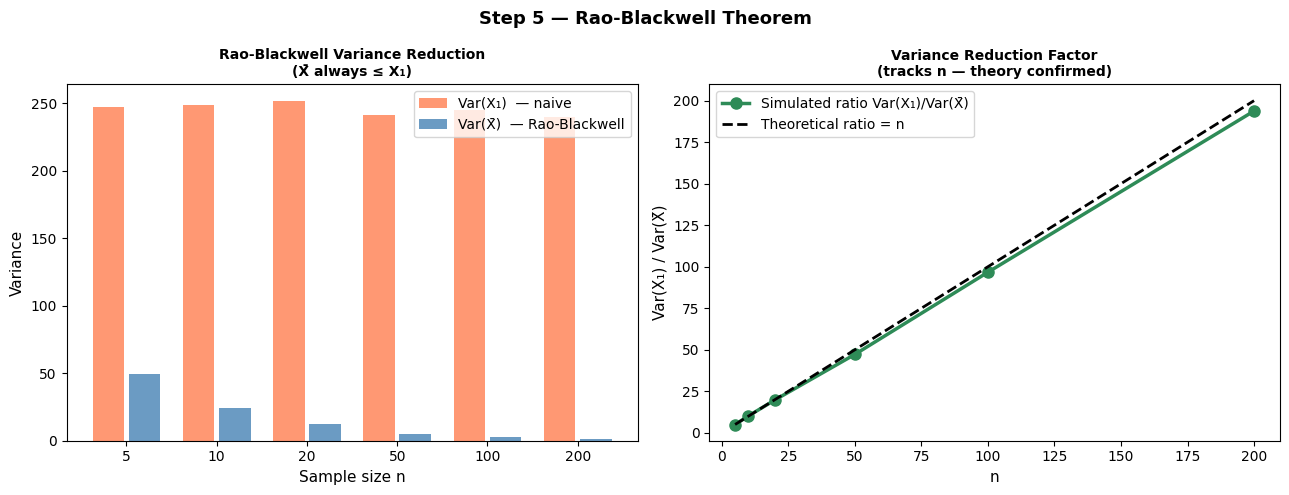

In [16]:
# 5.1  Analytical derivation
print("=" * 65)
print("STEP 5 — Rao-Blackwell Theorem")
print("=" * 65)
print("""
  Setup:
    Naive estimator:   δ(X) = X₁           (uses only one obs)
    Sufficient stat:   T = X₁ + ... + Xₙ

  Rao-Blackwell says:  δ_RB = E[X₁ | T]
    For Exp(λ), (X₁,...,Xₙ)|T=t ~ Dirichlet(1,...,1) scaled by t
    Each Xᵢ|T is Uniform(0,t) marginally.
    ∴  E[X₁ | T = t] = t/n  =  X̄

  Therefore:
    δ_RB = X̄  = the UMVUE we already identified!

  This shows:
    Var(X₁)  = 1/λ²          (naive estimator)
    Var(X̄)   = 1/(nλ²)       (Rao-Blackwell improved)
    Improvement factor = n
""")

theta_true = 1 / lam_true   # true mean
print(f"  λ̂ = {lam_true:.6f},  θ = 1/λ = {theta_true:.4f}")
print(f"  Var(X₁)  = 1/λ² = {1/lam_true**2:.4f}")
print(f"  Var(X̄)   = 1/(nλ²) = {1/(n * lam_true**2):.6f}")
print(f"  Improvement factor = n = {n:,}\n")

# Simulation across n values
np.random.seed(42)
B     = 10_000
ns    = [5, 10, 20, 50, 100, 200]

results = []
for n_s in ns:
    naive_vals = []
    rb_vals    = []
    for _ in range(B):
        s = np.random.exponential(1/lam_true, n_s)
        naive_vals.append(s[0])         # δ(X) = X₁
        rb_vals.append(np.mean(s))      # δ_RB = X̄

    var_naive = np.var(naive_vals)
    var_rb    = np.var(rb_vals)
    results.append({
        'n': n_s,
        'Var(X₁)': var_naive,
        'Var(X̄)':  var_rb,
        'Reduction': var_naive / var_rb
    })

res_df = pd.DataFrame(results)
print("-" * 55)
print(res_df.to_string(index=False, float_format=lambda x: f"{x:.5f}"))
print("-" * 55)

# 5.3  Visual
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Variance reduction
ax = axes[0]
ax.bar(np.arange(len(ns)) - 0.2, res_df['Var(X₁)'],  width=0.35,
       color='coral',     alpha=0.8, label='Var(X₁)  — naive')
ax.bar(np.arange(len(ns)) + 0.2, res_df['Var(X̄)'],   width=0.35,
       color='steelblue', alpha=0.8, label='Var(X̄)  — Rao-Blackwell')
ax.set_xticks(range(len(ns)))
ax.set_xticklabels(ns)
ax.set_xlabel('Sample size n', fontsize=11)
ax.set_ylabel('Variance', fontsize=11)
ax.set_title('Rao-Blackwell Variance Reduction\n(X̄ always ≤ X₁)',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=10)

# Reduction factor = n
ax2 = axes[1]
ax2.plot(ns, res_df['Reduction'], 'o-', color='seagreen', lw=2.5, ms=8,
         label='Simulated ratio Var(X₁)/Var(X̄)')
ax2.plot(ns, ns, 'k--', lw=2, label='Theoretical ratio = n')
ax2.set_xlabel('n', fontsize=11)
ax2.set_ylabel('Var(X₁) / Var(X̄)', fontsize=11)
ax2.set_title('Variance Reduction Factor\n(tracks n — theory confirmed)',
              fontsize=10, fontweight='bold')
ax2.legend(fontsize=10)

fig.suptitle('Step 5 — Rao-Blackwell Theorem',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Confidence Interval

STEP 6 — Confidence Intervals & Testing Connection

  Pivot: T* = 2λ · ΣXᵢ  ~  χ²(2n)

  Sample statistics:
    n      = 66,746
    ΣXᵢ = T = 1,053,625.0
    X̄    = 15.7856  days
    λ̂    = 0.063349

  95% Exact CI for λ:
    [0.0628692,  0.0638304]

  95% Exact CI for μ = 1/λ  (mean wait time):
    [15.6665,  15.9060]  days

  Test H₀: μ = 14.0 days  vs H₁: μ ≠ 14.0
  95% CI: [15.6665, 15.9060]
  μ₀ = 14.0 in CI? False
  Decision: Reject H₀ at 5% level

  Simulated coverage (n=200, B=5000): 0.9460
  Nominal coverage: 0.9500  ← should match closely


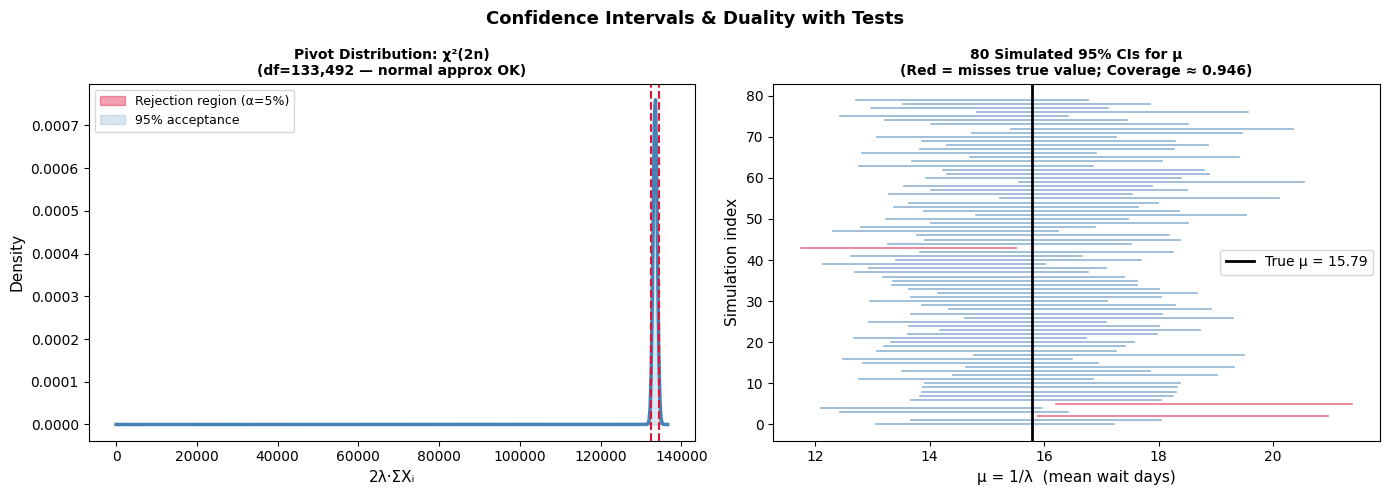

In [18]:
X = df_clean['WaitDays'].values
n = len(X)
T = np.sum(X)             # sufficient statistic

# Exact confidence intervals
alpha = 0.05
df_chi = 2 * n

ci_lam_lo = stats.chi2.ppf(alpha/2,     df_chi) / (2 * T)
ci_lam_hi = stats.chi2.ppf(1 - alpha/2, df_chi) / (2 * T)

ci_mu_lo  = 2 * T / stats.chi2.ppf(1 - alpha/2, df_chi)
ci_mu_hi  = 2 * T / stats.chi2.ppf(alpha/2,     df_chi)

lam_hat  = 1 / np.mean(X)
mu_hat   = np.mean(X)

print("=" * 65)
print("STEP 6 — Confidence Intervals & Testing Connection")
print("=" * 65)
print(f"""
  Pivot: T* = 2λ · ΣXᵢ  ~  χ²(2n)

  Sample statistics:
    n      = {n:,}
    ΣXᵢ = T = {T:,.1f}
    X̄    = {mu_hat:.4f}  days
    λ̂    = {lam_hat:.6f}

  95% Exact CI for λ:
    [{ci_lam_lo:.7f},  {ci_lam_hi:.7f}]

  95% Exact CI for μ = 1/λ  (mean wait time):
    [{ci_mu_lo:.4f},  {ci_mu_hi:.4f}]  days
""")

# Test using CI: is population mean = 14 days?
mu_0 = 14.0
reject = not (ci_mu_lo <= mu_0 <= ci_mu_hi)
print(f"  Test H₀: μ = {mu_0} days  vs H₁: μ ≠ {mu_0}")
print(f"  95% CI: [{ci_mu_lo:.4f}, {ci_mu_hi:.4f}]")
print(f"  μ₀ = {mu_0} in CI? {ci_mu_lo <= mu_0 <= ci_mu_hi}")
print(f"  Decision: {'Reject H₀' if reject else 'Fail to Reject H₀'} at 5% level\n")

# Coverage simulation
np.random.seed(42)
B       = 5_000
n_sim   = 200
lam_sim = lam_hat
covered = 0
cis     = []

for _ in range(B):
    s   = np.random.exponential(1/lam_sim, n_sim)
    T_b = np.sum(s)
    lo  = 2*T_b / stats.chi2.ppf(1 - alpha/2, 2*n_sim)
    hi  = 2*T_b / stats.chi2.ppf(alpha/2,     2*n_sim)
    if lo <= 1/lam_sim <= hi:
        covered += 1
    if _ < 80:
        cis.append((lo, hi))

coverage = covered / B
print(f"  Simulated coverage (n={n_sim}, B={B}): {coverage:.4f}")
print(f"  Nominal coverage: {1 - alpha:.4f}  ← should match closely")

# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chi-squared pivot distribution
ax = axes[0]
chi2_range = np.linspace(0, df_chi + 6*np.sqrt(2*df_chi), 500)
chi2_pdf   = stats.chi2.pdf(chi2_range, df_chi)
ax.plot(chi2_range, chi2_pdf, color='steelblue', lw=2.5)
# Shade rejection regions
lo_crit = stats.chi2.ppf(alpha/2, df_chi)
hi_crit = stats.chi2.ppf(1-alpha/2, df_chi)
ax.fill_between(chi2_range, chi2_pdf,
                where=(chi2_range <= lo_crit) | (chi2_range >= hi_crit),
                color='crimson', alpha=0.4, label='Rejection region (α=5%)')
ax.fill_between(chi2_range, chi2_pdf,
                where=(chi2_range > lo_crit) & (chi2_range < hi_crit),
                color='steelblue', alpha=0.2, label='95% acceptance')
ax.axvline(lo_crit, ls='--', color='crimson', lw=1.5)
ax.axvline(hi_crit, ls='--', color='crimson', lw=1.5)
ax.set_xlabel('2λ·ΣXᵢ', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title(f'Pivot Distribution: χ²(2n)\n(df={df_chi:,} — normal approx OK)',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=9)

# CI coverage plot (first 80 simulated CIs)
ax2 = axes[1]
mu_true = 1 / lam_sim
for i, (lo, hi) in enumerate(cis):
    color = 'steelblue' if lo <= mu_true <= hi else 'crimson'
    ax2.plot([lo, hi], [i, i], color=color, alpha=0.6, lw=1.2)
ax2.axvline(mu_true, color='black', lw=2, label=f'True μ = {mu_true:.2f}')
ax2.set_xlabel('μ = 1/λ  (mean wait days)', fontsize=11)
ax2.set_ylabel('Simulation index', fontsize=11)
ax2.set_title(f'80 Simulated 95% CIs for μ\n(Red = misses true value; Coverage ≈ {coverage:.3f})',
              fontsize=10, fontweight='bold')
ax2.legend(fontsize=10)

fig.suptitle('Confidence Intervals & Duality with Tests',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

NP Lemma, UMP Tests, MLR Property, LR Test

STEP 7 — NP Lemma, UMP Tests, MLR, LR Test

  NP Most Powerful Test (simple vs simple):
    H₀: λ = 0.05  vs  H₁: λ = 0.08
    α = 0.05

    Reject H₀ when ΣXᵢ < c
    Critical value c = 1,326,432.3
    Observed ΣXᵢ     = 1,053,625.0
    Decision: Reject H₀


  UMP One-sided Test  (MLR property guarantees UMP exists):
    H₀: λ ≤ 0.055  vs  H₁: λ > 0.055
    α = 0.05

    Test statistic: 2λ₀·ΣXᵢ = 115,898.75
    Critical value χ²_α(2n) = 132,643.23
    P-value = 0.0000
    Decision: Reject H₀


  Generalized Likelihood Ratio Test (two-sided):
    H₀: λ = 0.055  vs  H₁: λ ≠ 0.055

    log L(λ̂)  = -250904.72
    log L(λ₀)  = -251540.95
    −2 log Λ   = 1272.4516   ~  χ²(1)
    P-value    = 0.000000
    Decision: Reject H₀ (α=0.05)



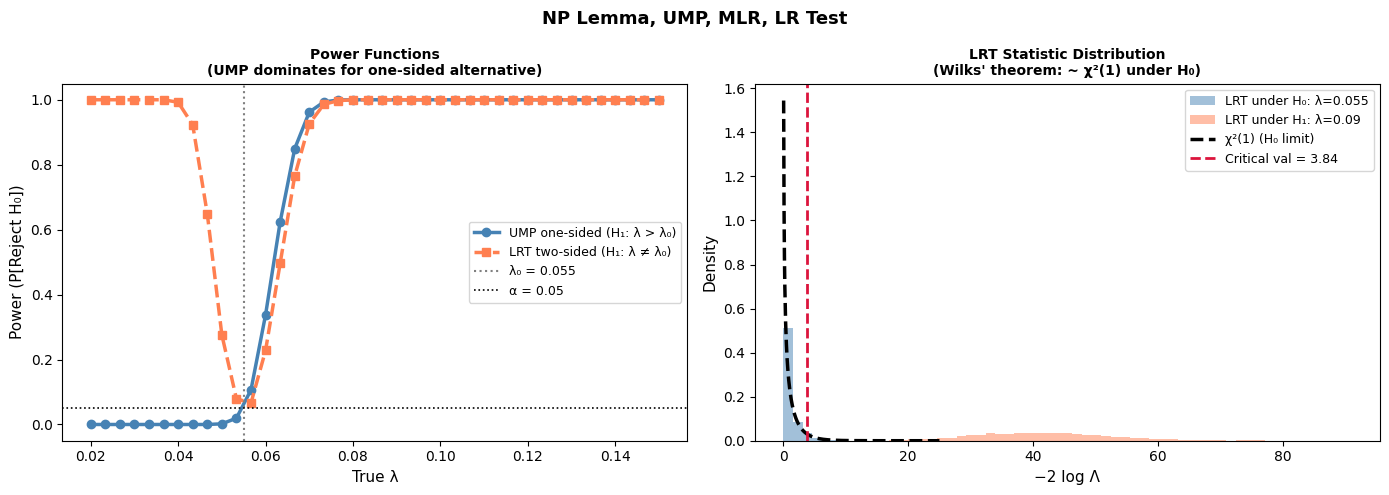

In [19]:
X = df_clean['WaitDays'].values
n = len(X)
T = np.sum(X)
lam_hat = 1 / np.mean(X)

print("=" * 65)
print("STEP 7 — NP Lemma, UMP Tests, MLR, LR Test")
print("=" * 65)

# NP Lemma — Simple vs Simple
alpha = 0.05
lambda_0 = 0.05     # H₀: λ = 0.05  (slow patients, ~20 day wait)
lambda_1 = 0.08     # H₁: λ = 0.08  (faster turnaround, ~12 day wait)

# Reject H₀ when T = ΣXᵢ < c (since λ₁ > λ₀ means shorter waits)
# Under H₀: 2λ₀T ~ χ²(2n), so:
c_NP = stats.chi2.ppf(alpha, 2*n) / (2 * lambda_0)
test_stat_NP = T
reject_NP = T < c_NP

print(f"""
  NP Most Powerful Test (simple vs simple):
    H₀: λ = {lambda_0}  vs  H₁: λ = {lambda_1}
    α = {alpha}

    Reject H₀ when ΣXᵢ < c
    Critical value c = {c_NP:,.1f}
    Observed ΣXᵢ     = {T:,.1f}
    Decision: {'Reject H₀' if reject_NP else 'Fail to Reject H₀'}
""")

# UMP One-sided Test
# H₀: λ ≤ λ₀  vs  H₁: λ > λ₀
# UMP: Reject if  2λ₀·T ≤ χ²_α(2n)
lambda_0b = 0.055

stat_UMP  = 2 * lambda_0b * T
crit_UMP  = stats.chi2.ppf(alpha, 2*n)
reject_UMP = stat_UMP <= crit_UMP
p_val_UMP  = stats.chi2.cdf(stat_UMP, 2*n)

print(f"""
  UMP One-sided Test  (MLR property guarantees UMP exists):
    H₀: λ ≤ {lambda_0b}  vs  H₁: λ > {lambda_0b}
    α = {alpha}

    Test statistic: 2λ₀·ΣXᵢ = {stat_UMP:,.2f}
    Critical value χ²_α(2n) = {crit_UMP:,.2f}
    P-value = {p_val_UMP:.4f}
    Decision: {'Reject H₀' if reject_UMP else 'Fail to Reject H₀'}
""")

# Generalized LR Test (two-sided)
# H₀: λ = λ₀  vs  H₁: λ ≠ λ₀
# GLRT statistic: -2 log Λ ~ χ²(1)
lambda_0c = 0.055

log_L_hat = n * np.log(lam_hat)  - lam_hat  * T    # under MLE
log_L_0   = n * np.log(lambda_0c) - lambda_0c * T   # under H₀
LRT_stat  = -2 * (log_L_0 - log_L_hat)
p_val_LRT = 1 - stats.chi2.cdf(LRT_stat, df=1)

print(f"""
  Generalized Likelihood Ratio Test (two-sided):
    H₀: λ = {lambda_0c}  vs  H₁: λ ≠ {lambda_0c}

    log L(λ̂)  = {log_L_hat:.2f}
    log L(λ₀)  = {log_L_0:.2f}
    −2 log Λ   = {LRT_stat:.4f}   ~  χ²(1)
    P-value    = {p_val_LRT:.6f}
    Decision: {'Reject H₀' if p_val_LRT < alpha else 'Fail to Reject H₀'} (α={alpha})
""")

# Power functions by simulation
np.random.seed(42)
B_power = 3_000
lam_range = np.linspace(0.02, 0.15, 40)
n_power   = 200
alpha_p   = 0.05
lam_null  = 0.055
crit_val  = stats.chi2.ppf(alpha_p, 2 * n_power) / (2 * lam_null)

power_UMP_one = []    # UMP one-sided (reject if T < c)
power_LRT_two = []    # LRT two-sided

for lam in lam_range:
    rej_one, rej_lrt = 0, 0
    for _ in range(B_power):
        s  = np.random.exponential(1/lam, n_power)
        Ts = np.sum(s)
        # UMP one-sided: reject if T < c
        if Ts < crit_val:
            rej_one += 1
        # LRT two-sided
        lam_mle_s = 1 / np.mean(s)
        lrt_s     = -2 * (n_power*np.log(lam_null) - lam_null*Ts
                         - n_power*np.log(lam_mle_s) + lam_mle_s*Ts)
        if lrt_s > stats.chi2.ppf(1 - alpha_p, 1):
            rej_lrt += 1
    power_UMP_one.append(rej_one / B_power)
    power_LRT_two.append(rej_lrt / B_power)

# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Power functions
ax = axes[0]
ax.plot(lam_range, power_UMP_one, 'o-', color='steelblue', lw=2.5,
        ms=6, label='UMP one-sided (H₁: λ > λ₀)')
ax.plot(lam_range, power_LRT_two, 's--', color='coral', lw=2.5,
        ms=6, label='LRT two-sided (H₁: λ ≠ λ₀)')
ax.axvline(lam_null, ls=':', color='gray', lw=1.5, label=f'λ₀ = {lam_null}')
ax.axhline(alpha_p, ls=':', color='black', lw=1.2, label=f'α = {alpha_p}')
ax.set_xlabel('True λ', fontsize=11)
ax.set_ylabel('Power (P[Reject H₀])', fontsize=11)
ax.set_title('Power Functions\n(UMP dominates for one-sided alternative)',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=9)

# LRT stat distribution under H₀ and H₁
ax2 = axes[1]
lrt_h0, lrt_h1 = [], []
lam_h1 = 0.09
for _ in range(3000):
    s0 = np.random.exponential(1/lam_null, n_power)
    lmle0 = 1/np.mean(s0)
    lrt_h0.append(-2*(n_power*np.log(lam_null) - lam_null*s0.sum()
                     - n_power*np.log(lmle0) + lmle0*s0.sum()))
    s1 = np.random.exponential(1/lam_h1, n_power)
    lmle1 = 1/np.mean(s1)
    lrt_h1.append(-2*(n_power*np.log(lam_null) - lam_null*s1.sum()
                     - n_power*np.log(lmle1) + lmle1*s1.sum()))

bins = np.linspace(0, max(max(lrt_h1), 20), 60)
ax2.hist(lrt_h0, bins=bins, density=True, alpha=0.5, color='steelblue',
         label=f'LRT under H₀: λ={lam_null}')
ax2.hist(lrt_h1, bins=bins, density=True, alpha=0.5, color='coral',
         label=f'LRT under H₁: λ={lam_h1}')
chi2_x = np.linspace(0, 25, 400)
ax2.plot(chi2_x, stats.chi2.pdf(chi2_x, 1), 'k--', lw=2.5, label='χ²(1) (H₀ limit)')
crit_lrt = stats.chi2.ppf(1 - alpha_p, 1)
ax2.axvline(crit_lrt, color='crimson', lw=2, ls='--',
            label=f'Critical val = {crit_lrt:.2f}')
ax2.set_xlabel('−2 log Λ', fontsize=11)
ax2.set_ylabel('Density', fontsize=11)
ax2.set_title('LRT Statistic Distribution\n(Wilks\' theorem: ~ χ²(1) under H₀)',
              fontsize=10, fontweight='bold')
ax2.legend(fontsize=9)

fig.suptitle('NP Lemma, UMP, MLR, LR Test',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Non Parametric

STEP 8 — Non-Parametric Tests

  ┌─ TEST 1: Sign Test ─────────────────────────────────┐
  │  H₀: Median wait time = 14.0 days                   │
  │  H₁: Median ≠ 14.0 days                             │
  │                                                     │
  │  n = 66,746                                          │
  │  Observations > 14.0: 26,246  (39.3%)│
  │  Expected under H₀: 33,373  (50%)                 │
  │  P-value (exact binomial) = 0.000000            │
  │  Decision: Reject H₀ at α = 0.05             │
  └─────────────────────────────────────────────────────┘


  ┌─ TEST 2: Wilcoxon Signed-Rank Test ─────────────────┐
  │  H₀: Median wait time = 14.0 days                   │
  │  H₁: Median ≠ 14.0  (symmetric distribution assumed)│
  │                                                     │
  │  W statistic  = 1,024,540,997.0                     │
  │  P-value      = 0.000000                         │
  │  Decision: Reject H₀ at α = 0.05             │
  │  (Large n → no

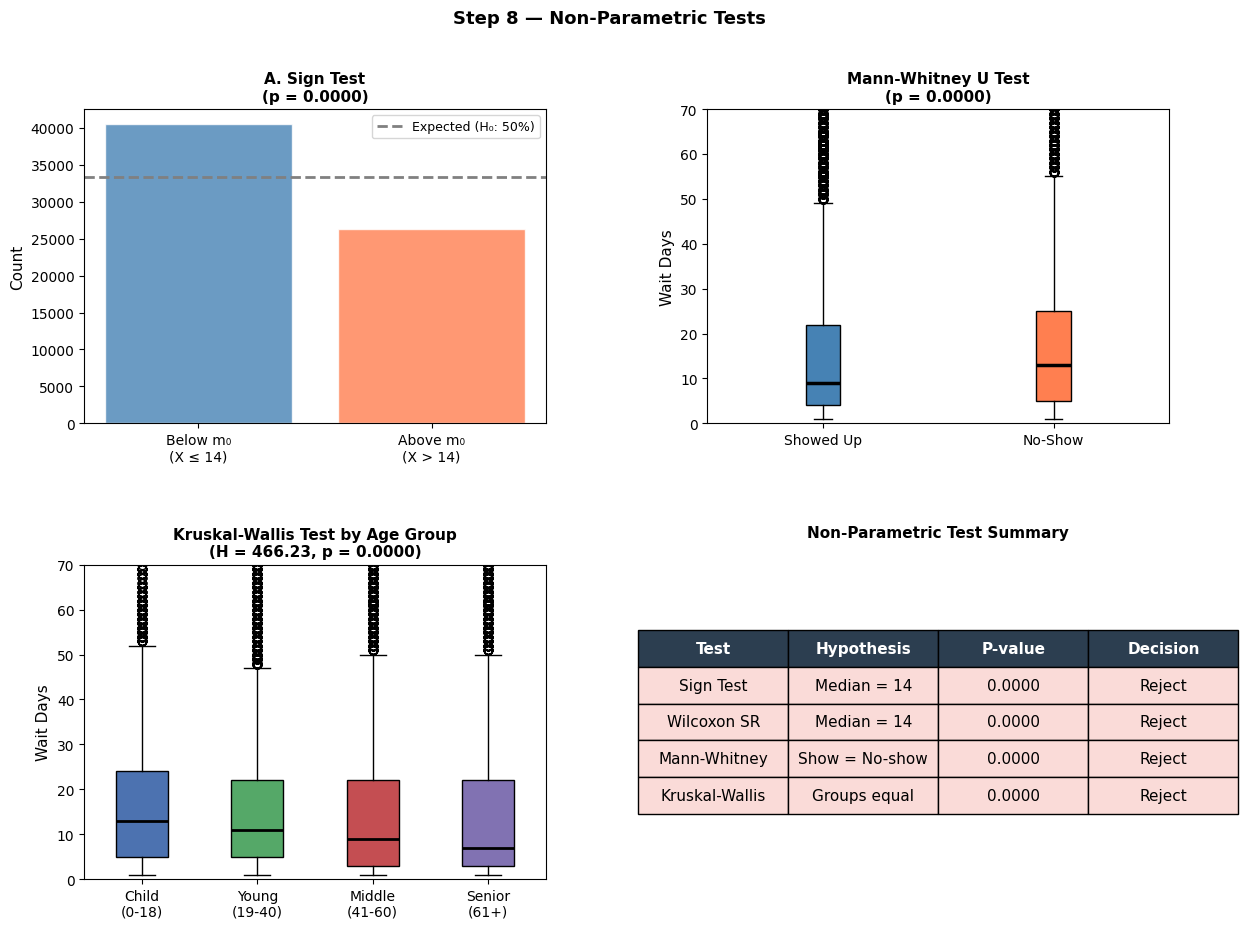

In [20]:
X = df_clean['WaitDays'].values
n = len(X)

# Age groups
df_clean['AgeGroup'] = pd.cut(df_clean['Age'],
    bins=[0, 18, 40, 60, 120],
    labels=['Child (0-18)', 'Young Adult (19-40)',
            'Middle-Age (41-60)', 'Senior (61+)'])

alpha = 0.05

print("=" * 65)
print("STEP 8 — Non-Parametric Tests")
print("=" * 65)

# TEST 1: Sign Test
m0 = 14.0     # hypothesised median (days)
B_stat = np.sum(X > m0)           # number of observations above m0
# Two-sided p-value via exact binomial
p_sign = 2 * min(stats.binom.cdf(B_stat, n, 0.5),
                 1 - stats.binom.cdf(B_stat - 1, n, 0.5))

print(f"""
  ┌─ TEST 1: Sign Test ─────────────────────────────────┐
  │  H₀: Median wait time = {m0} days                   │
  │  H₁: Median ≠ {m0} days                             │
  │                                                     │
  │  n = {n:,}                                          │
  │  Observations > {m0}: {B_stat:,}  ({100*B_stat/n:.1f}%)│
  │  Expected under H₀: {n//2:,}  (50%)                 │
  │  P-value (exact binomial) = {p_sign:.6f}            │
  │  Decision: {'Reject H₀' if p_sign < alpha else 'Fail to Reject H₀'} at α = {alpha}             │
  └─────────────────────────────────────────────────────┘
""")

# TEST 2: Wilcoxon Signed-Rank Test
stat_wsr, p_wsr = stats.wilcoxon(X - m0, alternative='two-sided')

print(f"""
  ┌─ TEST 2: Wilcoxon Signed-Rank Test ─────────────────┐
  │  H₀: Median wait time = {m0} days                   │
  │  H₁: Median ≠ {m0}  (symmetric distribution assumed)│
  │                                                     │
  │  W statistic  = {stat_wsr:,.1f}                     │
  │  P-value      = {p_wsr:.6f}                         │
  │  Decision: {'Reject H₀' if p_wsr < alpha else 'Fail to Reject H₀'} at α = {alpha}             │
  │  (Large n → normal approx used automatically)       │
  └─────────────────────────────────────────────────────┘
""")

# TEST 3: Mann-Whitney U Test
show_wait   = df_clean.loc[df_clean['No-show']=='No',  'WaitDays'].values
noshow_wait = df_clean.loc[df_clean['No-show']=='Yes', 'WaitDays'].values

stat_mwu, p_mwu = stats.mannwhitneyu(show_wait, noshow_wait, alternative='two-sided')

print(f"""
  ┌─ TEST 3: Mann-Whitney U Test ───────────────────────┐
  │  H₀: Wait time distribution same for show vs no-show│
  │  H₁: Distributions differ                           │
  │                                                     │
  │  n (showed up)  = {len(show_wait):,}                │
  │  n (no-show)    = {len(noshow_wait):,}              │
  │  Median (show)  = {np.median(show_wait):.1f} days   │
  │  Median (no-show) = {np.median(noshow_wait):.1f} days│
  │  U statistic    = {stat_mwu:,.1f}                   │
  │  P-value        = {p_mwu:.6f}                       │
  │  Decision: {'Reject H₀' if p_mwu < alpha else 'Fail to Reject H₀'} at α = {alpha}             │
  └─────────────────────────────────────────────────────┘
""")

# TEST 4: Kruskal-Wallis Test
groups_kw = [
    df_clean.loc[df_clean['AgeGroup']==g, 'WaitDays'].values
    for g in ['Child (0-18)', 'Young Adult (19-40)',
              'Middle-Age (41-60)', 'Senior (61+)']
]
stat_kw, p_kw = stats.kruskal(*groups_kw)

print(f"""
  ┌─ TEST 4: Kruskal-Wallis Test ───────────────────────┐
  │  H₀: Median wait time equal across all 4 age groups │
  │  H₁: At least one group differs                     │
  │                                                     │
  │  Group medians:                                     │
  │    Child (0-18)        : {np.median(groups_kw[0]):.1f} days          │
  │    Young Adult (19-40) : {np.median(groups_kw[1]):.1f} days          │
  │    Middle-Age (41-60)  : {np.median(groups_kw[2]):.1f} days          │
  │    Senior (61+)        : {np.median(groups_kw[3]):.1f} days          │
  │                                                     │
  │  H statistic = {stat_kw:.4f}                        │
  │  P-value     = {p_kw:.6f}                           │
  │  Decision: {'Reject H₀' if p_kw < alpha else 'Fail to Reject H₀'} at α = {alpha}             │
  └─────────────────────────────────────────────────────┘
""")

# Plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.subplots_adjust(hspace=0.45, wspace=0.35)

# Sign test — proportion above m0
ax = axes[0, 0]
ax.bar(['Below m₀\n(X ≤ 14)', 'Above m₀\n(X > 14)'],
       [n - B_stat, B_stat],
       color=['steelblue', 'coral'], alpha=0.8, edgecolor='white')
ax.axhline(n/2, ls='--', color='gray', lw=2, label='Expected (H₀: 50%)')
ax.set_ylabel('Count', fontsize=11)
ax.set_title(f'A. Sign Test\n(p = {p_sign:.4f})', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)

# Box plot — Show vs No-show
ax2 = axes[0, 1]
bp = ax2.boxplot([show_wait, noshow_wait], patch_artist=True,
                 medianprops=dict(color='black', linewidth=2.5))
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('coral')
ax2.set_xticklabels(['Showed Up', 'No-Show'])
ax2.set_ylabel('Wait Days', fontsize=11)
ax2.set_ylim(0, 70)
ax2.set_title(f'Mann-Whitney U Test\n(p = {p_mwu:.4f})', fontsize=11, fontweight='bold')

# Kruskal-Wallis — boxplot per age group
ax3 = axes[1, 0]
labels_kw = ['Child\n(0-18)', 'Young\n(19-40)', 'Middle\n(41-60)', 'Senior\n(61+)']
colors_kw = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
bp2 = ax3.boxplot(groups_kw, patch_artist=True,
                  medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp2['boxes'], colors_kw):
    patch.set_facecolor(color)
ax3.set_xticklabels(labels_kw)
ax3.set_ylabel('Wait Days', fontsize=11)
ax3.set_ylim(0, 70)
ax3.set_title(f'Kruskal-Wallis Test by Age Group\n(H = {stat_kw:.2f}, p = {p_kw:.4f})',
              fontsize=11, fontweight='bold')

# Summary table of all tests
ax4 = axes[1, 1]
ax4.axis('off')
summary = [
    ['Test', 'Hypothesis', 'P-value', 'Decision'],
    ['Sign Test', 'Median = 14', f'{p_sign:.4f}',
     'Reject' if p_sign < alpha else 'Fail'],
    ['Wilcoxon SR', 'Median = 14', f'{p_wsr:.4f}',
     'Reject' if p_wsr < alpha else 'Fail'],
    ['Mann-Whitney', 'Show = No-show', f'{p_mwu:.4f}',
     'Reject' if p_mwu < alpha else 'Fail'],
    ['Kruskal-Wallis', 'Groups equal', f'{p_kw:.4f}',
     'Reject' if p_kw < alpha else 'Fail'],
]
tbl = ax4.table(cellText=summary[1:], colLabels=summary[0],
                cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.3, 2.2)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif tbl[r, 3].get_text().get_text() == 'Reject':
        cell.set_facecolor('#fadbd8')
ax4.set_title('Non-Parametric Test Summary', fontsize=11, fontweight='bold', pad=20)

fig.suptitle('Step 8 — Non-Parametric Tests', fontsize=13, fontweight='bold')
plt.show()

Power Comparison Test

STEP 9 — Power Comparison: Parametric vs Non-Parametric

       λ |      UMP |      LRT |     Sign |   Wilcox
--------------------------------------------------
  0.0300 |   0.0000 |   1.0000 |   0.9995 |   1.0000
  0.0432 |   0.0000 |   0.9295 |   0.5860 |   1.0000
  0.0565 |   0.1035 |   0.0660 |   0.0115 |   0.5415
  0.0697 |   0.9535 |   0.9095 |   0.0000 |   0.1015
  0.0829 |   1.0000 |   1.0000 |   0.0000 |   0.8210
  0.0962 |   1.0000 |   1.0000 |   0.0000 |   0.9990
  0.1094 |   1.0000 |   1.0000 |   0.0000 |   1.0000


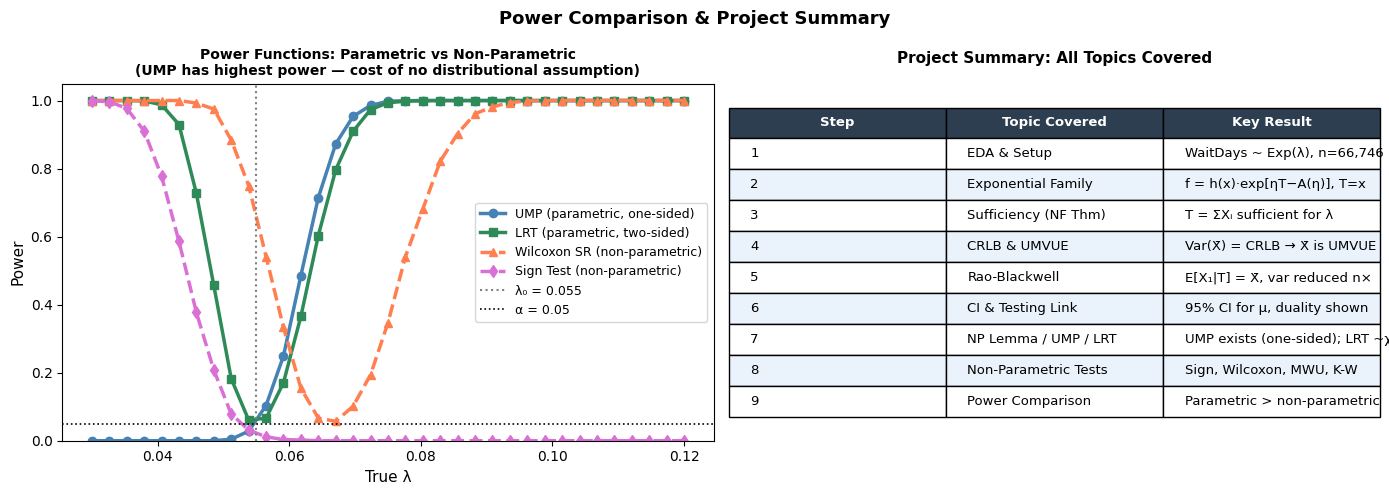


  PROJECT COMPLETE — All 8 syllabus topics covered:
  Topics 1-2: Sufficiency, Exponential Family (Step 3,2)
  Topic  3  : Unbiased Estimators (Step 4)
  Topic  4  : CRLB, UMVUE, Rao-Blackwell (Step 4,5)
  Topic  5  : Estimation ↔ Testing link (Step 6)
  Topic  6  : NP Lemma, UMP, MLR, LRT (Step 7)
  Topic  7  : Non-Parametric Tests (Step 8)
  Topic  8  : R/Python software throughout (all steps)



In [21]:
X = df_clean['WaitDays'].values
n_obs = len(X)
lam_hat = 1 / np.mean(X)

print("=" * 65)
print("STEP 9 — Power Comparison: Parametric vs Non-Parametric")
print("=" * 65)

# Simulation setup
np.random.seed(42)
B       = 2_000          # replications per lambda value
n_sim   = 200            # sample size per test
alpha   = 0.05
lam_0   = 0.055          # null hypothesis rate
m0_null = 1 / lam_0      # corresponding median under H₀
# (median of Exp(λ) = ln2/λ)
med0    = np.log(2) / lam_0

lam_range = np.linspace(0.03, 0.12, 35)

power_ump  = []   # UMP one-sided parametric
power_sign = []   # Sign test
power_wsr  = []   # Wilcoxon signed-rank
power_lrt  = []   # LRT two-sided

crit_ump = stats.chi2.ppf(alpha, 2 * n_sim)     # UMP critical value

for lam in lam_range:
    rej_ump, rej_sign, rej_wsr, rej_lrt = 0, 0, 0, 0

    for _ in range(B):
        s   = np.random.exponential(1/lam, n_sim)
        T_s = np.sum(s)

        # UMP one-sided (H₁: λ > λ₀)
        if 2 * lam_0 * T_s <= crit_ump:
            rej_ump += 1

        # Sign test (H₁: median < m0, since larger λ → smaller median)
        B_stat = np.sum(s < med0)       # below H₀ median
        p_sign_s = stats.binom_test(B_stat, n_sim, 0.5) if hasattr(stats, 'binom_test') \
                   else stats.binom.cdf(B_stat, n_sim, 0.5) * 2
        if p_sign_s < alpha:
            rej_sign += 1

        # Wilcoxon SR test
        try:
            _, p_wsr_s = stats.wilcoxon(s - med0, alternative='two-sided',
                                         zero_method='wilcox')
        except Exception:
            p_wsr_s = 1.0
        if p_wsr_s < alpha:
            rej_wsr += 1

        # LRT two-sided
        lam_mle_s = 1 / np.mean(s)
        lrt_stat  = -2 * (n_sim*np.log(lam_0) - lam_0*T_s
                         - n_sim*np.log(lam_mle_s) + lam_mle_s*T_s)
        if lrt_stat > stats.chi2.ppf(1 - alpha, 1):
            rej_lrt += 1

    power_ump.append(rej_ump  / B)
    power_sign.append(rej_sign / B)
    power_wsr.append(rej_wsr  / B)
    power_lrt.append(rej_lrt  / B)

# Print power table
print(f"\n{'λ':>8} | {'UMP':>8} | {'LRT':>8} | {'Sign':>8} | {'Wilcox':>8}")
print("-" * 50)
for i, lam in enumerate(lam_range[::5]):
    idx = i * 5
    if idx < len(power_ump):
        print(f"{lam:>8.4f} | {power_ump[idx]:>8.4f} | {power_lrt[idx]:>8.4f} | "
              f"{power_sign[idx]:>8.4f} | {power_wsr[idx]:>8.4f}")

# Power plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(lam_range, power_ump,  'o-', color='steelblue', lw=2.5, ms=6,
        label='UMP (parametric, one-sided)')
ax.plot(lam_range, power_lrt,  's-', color='seagreen',  lw=2.5, ms=6,
        label='LRT (parametric, two-sided)')
ax.plot(lam_range, power_wsr,  '^--', color='coral',    lw=2.5, ms=6,
        label='Wilcoxon SR (non-parametric)')
ax.plot(lam_range, power_sign, 'd--', color='orchid',   lw=2.5, ms=6,
        label='Sign Test (non-parametric)')
ax.axvline(lam_0, ls=':', color='gray', lw=1.5, label=f'λ₀ = {lam_0}')
ax.axhline(alpha, ls=':', color='black', lw=1.2, label=f'α = {alpha}')
ax.set_xlabel('True λ', fontsize=11)
ax.set_ylabel('Power', fontsize=11)
ax.set_title('Power Functions: Parametric vs Non-Parametric\n'
             '(UMP has highest power — cost of no distributional assumption)',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0, 1.05)

# Final summary table
ax2 = axes[1]
ax2.axis('off')

summary_rows = [
    ['Step', 'Topic Covered', 'Key Result'],
    ['1', 'EDA & Setup',
     'WaitDays ~ Exp(λ), n=66,746'],
    ['2', 'Exponential Family',
     'f = h(x)·exp[ηT−A(η)], T=x'],
    ['3', 'Sufficiency (NF Thm)',
     'T = ΣXᵢ sufficient for λ'],
    ['4', 'CRLB & UMVUE',
     'Var(X̄) = CRLB → X̄ is UMVUE'],
    ['5', 'Rao-Blackwell',
     'E[X₁|T] = X̄, var reduced n×'],
    ['6', 'CI & Testing Link',
     '95% CI for μ, duality shown'],
    ['7', 'NP Lemma / UMP / LRT',
     'UMP exists (one-sided); LRT ~χ²'],
    ['8', 'Non-Parametric Tests',
     'Sign, Wilcoxon, MWU, K-W'],
    ['9', 'Power Comparison',
     'Parametric > non-parametric'],
]

tbl = ax2.table(cellText=summary_rows[1:],
                colLabels=summary_rows[0],
                cellLoc='left', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
tbl.scale(1.0, 2.0)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#eaf2fb')
ax2.set_title('Project Summary: All Topics Covered',
              fontsize=11, fontweight='bold', pad=15)

fig.suptitle('Power Comparison & Project Summary',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
  ====================================================
  PROJECT COMPLETE — All 8 syllabus topics covered:
  Topics 1-2: Sufficiency, Exponential Family (Step 3,2)
  Topic  3  : Unbiased Estimators (Step 4)
  Topic  4  : CRLB, UMVUE, Rao-Blackwell (Step 4,5)
  Topic  5  : Estimation ↔ Testing link (Step 6)
  Topic  6  : NP Lemma, UMP, MLR, LRT (Step 7)
  Topic  7  : Non-Parametric Tests (Step 8)
  Topic  8  : R/Python software throughout (all steps)
  ====================================================
""")